# nb06 — короткие окна + ЕЖЕДНЕВНЫЙ пересчёт ADF

nb05 закрыл месячные окна: коинтеграция не переживает одно окно (lift ≈ 1 вперёд
при lift ≈ 8 внутри окна), а замороженный центр уезжает на 2.4σ за первый горизонт.
Осталась непроверенной **короткая часть шкалы** — дни, а не месяцы. Пользователь:
«мой алгоритм тоже пересчитывал ADF раз в день».

**Важное уточнение постановки.** При ежедневном рефите «frozen» и «rolling» в
прежнем смысле схлопываются: параметры, пересчитанные сегодня на трейлинговом окне,
**и есть** скользящая оценка. Настоящая развилка в другом — что делать с **уже
открытой** позицией:

- **ENTRY** — решение о выходе судим по параметрам, зафиксированным на входе;
- **REFIT** — судим по самому свежему дневному рефиту (центр и σ переопределяются
  под позицией, пока она открыта).

β самой позиции в обоих режимах фиксирована на входе — мы держим то, что купили;
пересчёт влияет только на **решения**, не на состав позиции.

## Сетка

| параметр | значения |
|---|---|
| окно формации L | 3, 7, 14, 30 дней |
| рефит | ежедневно (как в алгоритме пользователя) |
| режим решений | ENTRY / REFIT |
| вход / выход / стоп | \|z\|>2 / \|z\|<0.5 / \|z\|>4 |
| лимит удержания | 2·L |
| фильтр | p<0.05 (размер калиброван на синтетике) и β>0 |

Границы месяца больше **не** закрывают позиции принудительно (дефект nb04 §5).
Всё внутри TRAIN, OOS заперт.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from statsmodels.tsa.stattools import coint
from itertools import combinations
import time

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
LP = np.log(px.loc[TRAIN[0]:TRAIN[1], liq]).iloc[:-1]
PAIRS = [((a, b) if daily_m[a] <= daily_m[b] else (b, a)) for a, b in combinations(liq, 2)]
IY = np.array([liq.index(y) for y, x in PAIRS])
IX = np.array([liq.index(x) for y, x in PAIRS])
M = LP.values                      # (часы, символы)
HOURS = LP.index
COST = ROUND_TRIP_BPS / 100
print(f"символов {len(liq)}, пар {len(PAIRS)}, часов {len(HOURS)}: "
      f"{HOURS[0]} .. {HOURS[-1]}")

символов 43, пар 903, часов 13151: 2024-01-01 00:00:00+00:00 .. 2025-07-01 22:00:00+00:00


## 1. Быстрый EG-тест и калибровка порога

`statsmodels.coint` — 1.5 мс на пару. Нам нужно 547 дней × 903 пары × 4 окна
≈ 2 млн тестов, это часы. Пишем векторную реализацию (OLS + DF-регрессия остатка
без лагов) — она даёт t-статистику за ~30 мкс.

Порог отсечения **не берём из таблиц**, а калибруем на своих же данных: строим
синтетику из перемешанных доходностей (связи нет по построению) и берём 5-й
процентиль t-статистики. Тогда размер теста ровно 5% на нашей же выборке — это
надёжнее асимптотических критических значений.

Плюс проверяем согласие с `statsmodels` на реальных данных.

In [2]:
def eg_t(y, x):
    """t-статистика DF-теста остатка регрессии y на x (+const). Векторно по времени."""
    xc = x - x.mean()
    yc = y - y.mean()
    beta = (xc @ yc) / (xc @ xc)
    e = yc - beta * xc
    el, de = e[:-1], e[1:] - e[:-1]
    n = de.size
    sl, sde = el.sum(), de.sum()
    Sxx = el @ el - sl * sl / n
    Sxy = el @ de - sl * sde / n
    rho = Sxy / Sxx
    a = sde / n - rho * sl / n
    r = de - (a + rho * el)
    s2 = (r @ r) / (n - 2)
    return rho / np.sqrt(s2 / Sxx), beta, e.mean() + (y.mean() - beta * x.mean()), e.std()


def eg_t_all(W):
    """t, beta, mu, sd для ВСЕХ пар на окне W (часы x символы)."""
    out_t = np.empty(len(PAIRS)); out_b = np.empty(len(PAIRS))
    out_m = np.empty(len(PAIRS)); out_s = np.empty(len(PAIRS))
    for i in range(len(PAIRS)):
        y, x = W[:, IY[i]], W[:, IX[i]]
        xc, yc = x - x.mean(), y - y.mean()
        beta = (xc @ yc) / (xc @ xc)
        e = y - beta * x
        ec = e - e.mean()
        el, de = ec[:-1], ec[1:] - ec[:-1]
        n = de.size
        Sxx = el @ el - el.sum()**2 / n
        Sxy = el @ de - el.sum() * de.sum() / n
        rho = Sxy / Sxx
        a = de.sum() / n - rho * el.sum() / n
        r = de - (a + rho * el)
        s2 = (r @ r) / (n - 2)
        out_t[i] = rho / np.sqrt(s2 / Sxx)
        out_b[i] = beta
        out_m[i] = e.mean()
        out_s[i] = e.std()
    return out_t, out_b, out_m, out_s


# --- скорость ---
W = M[:24*14]
t0 = time.time(); _ = eg_t_all(W); dt = time.time() - t0
print(f"векторная версия: {dt*1e6/len(PAIRS):.0f} мкс на пару ({dt:.2f}s на 903 пары)")
t0 = time.time()
for i in range(60):
    coint(W[:, IY[i]], W[:, IX[i]], trend="c", maxlag=1, autolag=None)
print(f"statsmodels:      {(time.time()-t0)*1e6/60:.0f} мкс на пару "
      f"-> ускорение ~{((time.time()-t0)/60)/(dt/len(PAIRS)):.0f}x")

# --- калибровка порога на синтетике (связи нет по построению) ---
rng = np.random.default_rng(11)
LDAYS = [3, 7, 14, 30]
THR = {}
for L in LDAYS:
    ts = []
    for rep in range(3):
        seg = M[rep*2000: rep*2000 + 24*L]
        rets = np.diff(seg, axis=0)
        fake = np.cumsum(np.apply_along_axis(rng.permutation, 0, rets), axis=0)
        ts.append(eg_t_all(fake)[0])
    ts = np.concatenate(ts)
    THR[L] = float(np.percentile(ts, 5))
    print(f"L={L:>2}д: порог t (5% на синтетике) = {THR[L]:.3f}, "
          f"n={len(ts)} тестов на нуле")

# --- согласие с statsmodels на реальных данных ---
seg = M[3000:3000 + 24*14]
t_fast, _, _, _ = eg_t_all(seg)
p_sm = np.array([coint(seg[:, IY[i]], seg[:, IX[i]], trend="c", maxlag=1, autolag=None)[1]
                 for i in range(300)])
sel_fast = t_fast[:300] < THR[14]
sel_sm = p_sm < 0.05
agree = (sel_fast == sel_sm).mean()
print(f"\nсогласие с statsmodels (L=14д, 300 пар): {agree*100:.1f}%")
print(f"  отобрано быстрым тестом {sel_fast.sum()}, statsmodels {sel_sm.sum()}")
print(f"  corr(t_fast, -log10 p_sm) = "
      f"{np.corrcoef(-t_fast[:300], -np.log10(np.clip(p_sm,1e-9,1)))[0,1]:.3f}")

векторная версия: 25 мкс на пару (0.02s на 903 пары)
statsmodels:      296 мкс на пару -> ускорение ~12x
L= 3д: порог t (5% на синтетике) = -3.341, n=2709 тестов на нуле
L= 7д: порог t (5% на синтетике) = -3.545, n=2709 тестов на нуле


L=14д: порог t (5% на синтетике) = -3.294, n=2709 тестов на нуле
L=30д: порог t (5% на синтетике) = -3.451, n=2709 тестов на нуле

согласие с statsmodels (L=14д, 300 пар): 95.7%
  отобрано быстрым тестом 24, statsmodels 23
  corr(t_fast, -log10 p_sm) = 0.885


## 2. Движок с ежедневным рефитом

Порядок строго причинный: рефит на данных **до конца дня d** включительно даёт
универсум и параметры для торговли **в день d+1**. Ни один бар из дня d+1 в
оценку не входит.

In [3]:
def daily_refit(L):
    """Ежедневный рефит на трейлинговом окне L дней. Возвращает массивы (дни x пары)."""
    day_ends = np.where(HOURS.hour == 23)[0]
    day_ends = day_ends[day_ends >= 24*L]
    T, B, MU, SD = [], [], [], []
    for de in day_ends:
        W = M[de - 24*L + 1: de + 1]
        t, b, mu, sd = eg_t_all(W)
        T.append(t); B.append(b); MU.append(mu); SD.append(sd)
    return (np.array(T), np.array(B), np.array(MU), np.array(SD), day_ends)


REFIT = {}
for L in LDAYS:
    t0 = time.time()
    REFIT[L] = daily_refit(L)
    sel = (REFIT[L][0] < THR[L]) & (REFIT[L][1] > 0)
    print(f"L={L:>2}д: {REFIT[L][0].shape[0]} дней рефита, "
          f"отобрано в среднем {sel.sum(axis=1).mean():.0f} пар/день "
          f"({sel.mean()*100:.1f}% пар), {time.time()-t0:.0f}s")

L= 3д: 544 дней рефита, отобрано в среднем 81 пар/день (8.9% пар), 13s


L= 7д: 540 дней рефита, отобрано в среднем 58 пар/день (6.5% пар), 13s


L=14д: 533 дней рефита, отобрано в среднем 104 пар/день (11.6% пар), 14s


L=30д: 517 дней рефита, отобрано в среднем 86 пар/день (9.5% пар), 14s


In [4]:
def run_sweep(L, mode, T, B, MU, SD, day_ends, zin=2.0, zout=0.5, zstop=4.0,
              max_hold_mult=2.0):
    """Сделки по всем парам. mode: 'ENTRY' (параметры входа) или 'REFIT' (свежие)."""
    sel = (T < THR[L]) & (B > 0)
    n_days = len(day_ends)
    max_hold = int(max_hold_mult * 24 * L)
    # для каждого часа — индекс дня рефита, чьи параметры действуют
    hour_day = np.full(len(HOURS), -1, dtype=int)
    for d in range(n_days):
        lo = day_ends[d] + 1
        hi = day_ends[d + 1] + 1 if d + 1 < n_days else len(HOURS)
        hour_day[lo:hi] = d
    valid = hour_day >= 0

    trades = []
    for i in range(len(PAIRS)):
        yv, xv = M[:, IY[i]], M[:, IX[i]]
        hd = hour_day
        b_cur = np.where(valid, B[np.clip(hd, 0, None), i], np.nan)
        mu_cur = np.where(valid, MU[np.clip(hd, 0, None), i], np.nan)
        sd_cur = np.where(valid, SD[np.clip(hd, 0, None), i], np.nan)
        ok = np.where(valid, sel[np.clip(hd, 0, None), i], False)
        if not ok.any():
            continue
        s_cur = yv - b_cur * xv
        z_cur = (s_cur - mu_cur) / sd_cur          # z по свежему рефиту
        idxs = np.where(ok & np.isfinite(z_cur) & (np.abs(z_cur) > zin)
                        & (np.abs(z_cur) <= zstop))[0]
        pos_until = -1
        for t_in in idxs:
            if t_in <= pos_until:
                continue
            beta_e = b_cur[t_in]
            mu_e, sd_e = mu_cur[t_in], sd_cur[t_in]
            g = 1 + abs(beta_e)
            side = -1 if z_cur[t_in] > 0 else 1
            s_pos = yv - beta_e * xv               # спред фактической позиции
            hi = min(t_in + max_hold, len(HOURS) - 1)
            reason = "time"
            t_out = hi
            for t in range(t_in + 1, hi + 1):
                if mode == "ENTRY":
                    z = (s_pos[t] - mu_e) / sd_e
                else:
                    if not valid[t]:
                        continue
                    z = z_cur[t]
                if abs(z) < zout:
                    reason, t_out = "target", t
                    break
                if abs(z) > zstop:
                    reason, t_out = "zstop", t
                    break
            pnl = side * (s_pos[t_out] - s_pos[t_in]) / g * 100 - COST
            trades.append((i, t_in, t_out, side, z_cur[t_in], reason, pnl, beta_e, g))
            pos_until = t_out
    df = pd.DataFrame(trades, columns=["pi", "i_in", "i_out", "side", "z_in",
                                       "reason", "pnl", "beta", "g"])
    if len(df):
        df["t_in"] = HOURS[df.i_in.values]
        df["t_out"] = HOURS[df.i_out.values]
        df["hours"] = df.i_out - df.i_in
        df["pair"] = [f"{PAIRS[p][0]}/{PAIRS[p][1]}" for p in df.pi]
    return df


rows, RES = [], {}
for L in LDAYS:
    for mode in ["ENTRY", "REFIT"]:
        t0 = time.time()
        d = run_sweep(L, mode, *REFIT[L])
        RES[(L, mode)] = d
        if not len(d):
            continue
        bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()
        rows.append({"L, дн": L, "режим": mode, "сделок": len(d),
                     "среднее %": round(d.pnl.mean(), 3),
                     "медиана %": round(d.pnl.median(), 2),
                     "std": round(d.pnl.std(), 2),
                     "среднее/std": round(d.pnl.mean()/d.pnl.std(), 3),
                     "% плюс": round((d.pnl > 0).mean()*100, 1),
                     "медиана ч": int(d.hours.median()),
                     "худшая %": round(d.pnl.min(), 1),
                     "мес +": f"{(bym>0).sum()}/{len(bym)}",
                     "сек": round(time.time()-t0)})
SW = pd.DataFrame(rows)
print("СВИП КОРОТКИХ ОКОН С ЕЖЕДНЕВНЫМ РЕФИТОМ (TRAIN, косты 21 bps)")
print(SW.to_string(index=False))

C:\Users\nvisary\AppData\Local\Temp\ipykernel_7644\807828202.py:75: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


C:\Users\nvisary\AppData\Local\Temp\ipykernel_7644\807828202.py:75: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


C:\Users\nvisary\AppData\Local\Temp\ipykernel_7644\807828202.py:75: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


C:\Users\nvisary\AppData\Local\Temp\ipykernel_7644\807828202.py:75: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


C:\Users\nvisary\AppData\Local\Temp\ipykernel_7644\807828202.py:75: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


C:\Users\nvisary\AppData\Local\Temp\ipykernel_7644\807828202.py:75: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


C:\Users\nvisary\AppData\Local\Temp\ipykernel_7644\807828202.py:75: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


СВИП КОРОТКИХ ОКОН С ЕЖЕДНЕВНЫМ РЕФИТОМ (TRAIN, косты 21 bps)
 L, дн режим  сделок  среднее %  медиана %  std  среднее/std  % плюс  медиана ч  худшая % мес +  сек
     3 ENTRY   57690     -0.165      -0.53 1.68       -0.098    40.4          6     -29.5  0/19    1
     3 REFIT   57781     -0.165      -0.36 1.64       -0.101    44.9          6     -23.9  0/19    1
     7 ENTRY   25249     -0.196      -0.58 2.21       -0.088    42.1         10     -20.2  0/19    0
     7 REFIT   25147     -0.192      -0.06 2.15       -0.089    49.6         10     -21.0  1/19    0
    14 ENTRY   23750     -0.195      -0.61 3.03       -0.064    44.3         18     -26.9  5/19    0
    14 REFIT   23530     -0.203       0.48 2.97       -0.068    53.6         18     -27.0  6/19    0
    30 ENTRY   10445     -0.213      -0.69 3.88       -0.055    44.6         30     -20.6  6/18    0
    30 REFIT   10162     -0.246       0.84 4.09       -0.060    55.3         31     -33.9  6/18    0


C:\Users\nvisary\AppData\Local\Temp\ipykernel_7644\807828202.py:75: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  bym = d.groupby(d.t_in.dt.to_period("M")).pnl.mean()


## 3. Синтетический baseline — обязательный

nb01 научил: правило «вход 2σ → выход 0.5σ» рисует красивую медиану даже на чистом
случайном блуждании. Поэтому весь свип прогоняем ещё раз на **перемешанных
доходностях**: та же машинерия, тот же отбор, но связи в данных нет по построению.
Любое превышение реальных чисел над этим baseline — и есть кандидат в сигнал.

In [5]:
rng2 = np.random.default_rng(99)
rets_all = np.diff(M, axis=0)
M_null = np.vstack([M[0], M[0] + np.cumsum(np.apply_along_axis(rng2.permutation, 0, rets_all),
                                          axis=0)])

M_real = M
rows_n = []
for L in LDAYS:
    globals()["M"] = M_null
    R = daily_refit(L)
    d = run_sweep(L, "REFIT", *R)
    globals()["M"] = M_real
    if not len(d):
        continue
    rows_n.append({"L, дн": L, "сделок": len(d),
                   "среднее %": round(d.pnl.mean(), 3),
                   "медиана %": round(d.pnl.median(), 2),
                   "среднее/std": round(d.pnl.mean()/d.pnl.std(), 3),
                   "% плюс": round((d.pnl > 0).mean()*100, 1),
                   "медиана ч": int(d.hours.median())})
NL = pd.DataFrame(rows_n)
print("BASELINE НА СИНТЕТИКЕ (связи нет по построению), режим REFIT")
print(NL.to_string(index=False))
print()
print("РЕАЛЬНОСТЬ МИНУС СИНТЕТИКА (то, что нельзя объяснить конструкцией правила):")
cmp_rows = []
for L in LDAYS:
    r = SW[(SW["L, дн"] == L) & (SW["режим"] == "REFIT")]
    n = NL[NL["L, дн"] == L]
    if not len(r) or not len(n):
        continue
    cmp_rows.append({"L, дн": L,
                     "реальное среднее %": r["среднее %"].iloc[0],
                     "синтетика %": n["среднее %"].iloc[0],
                     "разница п.п.": round(r["среднее %"].iloc[0] - n["среднее %"].iloc[0], 3),
                     "реальное ср/std": r["среднее/std"].iloc[0],
                     "синт ср/std": n["среднее/std"].iloc[0]})
print(pd.DataFrame(cmp_rows).to_string(index=False))

BASELINE НА СИНТЕТИКЕ (связи нет по построению), режим REFIT
 L, дн  сделок  среднее %  медиана %  среднее/std  % плюс  медиана ч
     3   18971     -0.279      -0.70       -0.095    43.4          6
     7    6725     -0.179      -0.33       -0.048    49.2         11
    14    6828     -0.339       1.49       -0.059    55.1         22
    30    2475      0.017       2.81        0.002    60.5         43

РЕАЛЬНОСТЬ МИНУС СИНТЕТИКА (то, что нельзя объяснить конструкцией правила):
 L, дн  реальное среднее %  синтетика %  разница п.п.  реальное ср/std  синт ср/std
     3              -0.165       -0.279         0.114           -0.101       -0.095
     7              -0.192       -0.179        -0.013           -0.089       -0.048
    14              -0.203       -0.339         0.136           -0.068       -0.059
    30              -0.246        0.017        -0.263           -0.060        0.002


[saved] notebooks\statarb\_out\nb06_sweep.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb06_sweep.png')

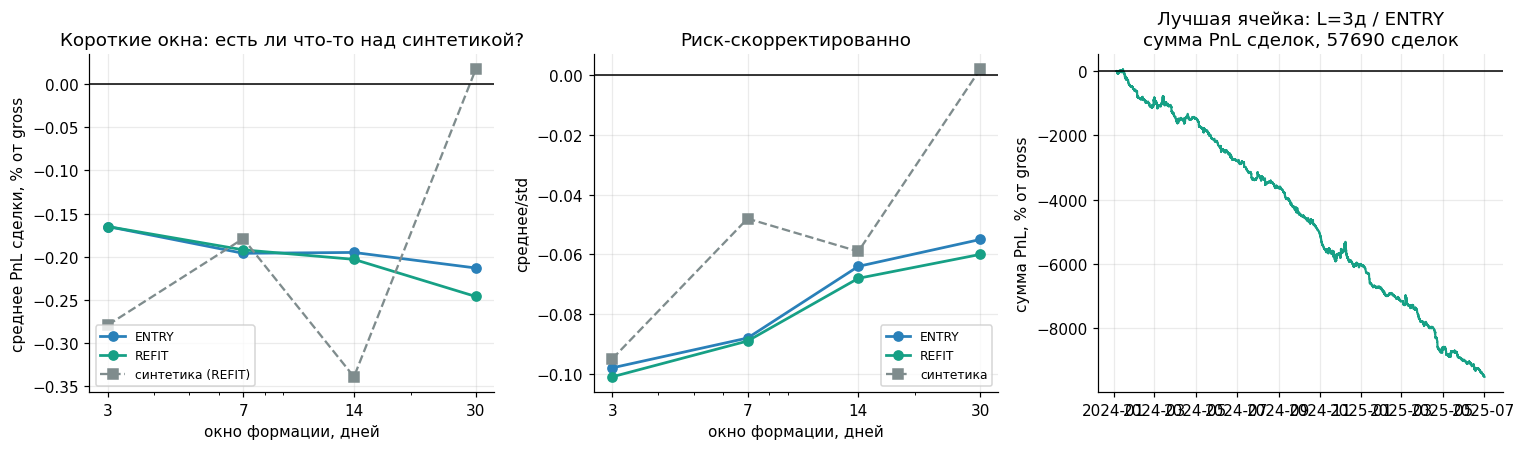

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for mode, c in [("ENTRY", "#2980b9"), ("REFIT", "#16a085")]:
    d = SW[SW["режим"] == mode]
    ax[0].plot(d["L, дн"], d["среднее %"], "o-", lw=1.8, color=c, label=mode)
if len(NL):
    ax[0].plot(NL["L, дн"], NL["среднее %"], "s--", lw=1.5, color="#7f8c8d",
               label="синтетика (REFIT)")
ax[0].axhline(0, color="black", lw=1)
ax[0].set_xscale("log"); ax[0].set_xticks(LDAYS); ax[0].set_xticklabels(LDAYS)
ax[0].set_xlabel("окно формации, дней"); ax[0].set_ylabel("среднее PnL сделки, % от gross")
ax[0].set_title("Короткие окна: есть ли что-то над синтетикой?"); ax[0].legend(fontsize=8)

for mode, c in [("ENTRY", "#2980b9"), ("REFIT", "#16a085")]:
    d = SW[SW["режим"] == mode]
    ax[1].plot(d["L, дн"], d["среднее/std"], "o-", lw=1.8, color=c, label=mode)
if len(NL):
    ax[1].plot(NL["L, дн"], NL["среднее/std"], "s--", lw=1.5, color="#7f8c8d", label="синтетика")
ax[1].axhline(0, color="black", lw=1)
ax[1].set_xscale("log"); ax[1].set_xticks(LDAYS); ax[1].set_xticklabels(LDAYS)
ax[1].set_xlabel("окно формации, дней"); ax[1].set_ylabel("среднее/std")
ax[1].set_title("Риск-скорректированно"); ax[1].legend(fontsize=8)

best = SW.sort_values("среднее %", ascending=False).iloc[0]
d = RES[(best["L, дн"], best["режим"])].sort_values("t_in")
ax[2].plot(d.t_in.values, d.pnl.cumsum().values, lw=1.4, color="#16a085")
ax[2].axhline(0, color="black", lw=1)
ax[2].set_title(f"Лучшая ячейка: L={best['L, дн']}д / {best['режим']}\n"
                f"сумма PnL сделок, {len(d)} сделок")
ax[2].set_ylabel("сумма PnL, % от gross")
show("nb06_sweep")

## 4. Gross против net: где именно теряются деньги

Все PnL выше — **за вычетом** костов (21 bps round-trip). Разложим: сколько даёт
сам спред и сколько забирают косты. Заодно посчитаем σ спреда для каждой длины
окна — потому что именно она задаёт масштаб выплаты, а кост фиксирован.

Ожидание, которое надо проверить: на коротком окне σ спреда мала, поэтому один и
тот же кост 21 bps съедает гораздо большую долю движения, чем на месячном окне
(в nb01 при месячной σ=364 bps кост был 0.058σ = 3.8% от хода 1.5σ).

In [7]:
rows = []
for L in LDAYS:
    T, B, MU, SD, de = REFIT[L]
    sel = (T < THR[L]) & (B > 0)
    g = 1 + np.abs(B)
    sd_pct = (SD / g * 100)[sel]                  # σ спреда в % от gross
    for mode in ["ENTRY", "REFIT"]:
        d = RES[(L, mode)]
        if not len(d):
            continue
        gross = d.pnl.mean() + COST
        rows.append({"L, дн": L, "режим": mode,
                     "σ спреда, % gross": round(float(np.median(sd_pct)), 3),
                     "кост в σ": round(COST / float(np.median(sd_pct)), 3),
                     "кост / ход 1.5σ, %": round(COST / (1.5*float(np.median(sd_pct)))*100, 1),
                     "GROSS среднее %": round(gross, 3),
                     "кост %": -round(COST, 3),
                     "NET среднее %": round(d.pnl.mean(), 3),
                     "GROSS в σ": round(gross / float(np.median(sd_pct)), 3)})
G = pd.DataFrame(rows)
print("РАЗЛОЖЕНИЕ GROSS / КОСТЫ / NET")
print(G.to_string(index=False))
print()
print("как читать: 'кост / ход 1.5σ' — какую долю теоретического хода (вход 2σ →")
print("выход 0.5σ) забирает round-trip. В nb01 на месячном окне это было 3.8%.")
print()
pos = G[G["GROSS среднее %"] > 0]
if len(pos):
    print("ячейки, где спред ДО костов даёт плюс:")
    print(pos[["L, дн", "режим", "GROSS среднее %", "NET среднее %", "GROSS в σ"]].to_string(index=False))
    print("\n-> сигнал до костов существует, но он меньше костов. Проверим, какой")
    print("   уровень костов нужен, чтобы выйти в ноль:")
    for _, r in pos.iterrows():
        print(f"   L={r['L, дн']:>2}д/{r['режим']:<5}: нужен round-trip <= "
              f"{r['GROSS среднее %']*100:.1f} bps (сейчас {ROUND_TRIP_BPS:.0f} bps, "
              f"т.е. в {ROUND_TRIP_BPS/(r['GROSS среднее %']*100):.1f}x меньше)")
else:
    print("ни одна ячейка не даёт плюс даже ДО костов.")

РАЗЛОЖЕНИЕ GROSS / КОСТЫ / NET
 L, дн режим  σ спреда, % gross  кост в σ  кост / ход 1.5σ, %  GROSS среднее %  кост %  NET среднее %  GROSS в σ
     3 ENTRY              0.541     0.388                25.9            0.045   -0.21         -0.165      0.083
     3 REFIT              0.541     0.388                25.9            0.045   -0.21         -0.165      0.083
     7 ENTRY              0.794     0.265                17.6            0.014   -0.21         -0.196      0.018
     7 REFIT              0.794     0.265                17.6            0.018   -0.21         -0.192      0.023
    14 ENTRY              1.168     0.180                12.0            0.015   -0.21         -0.195      0.013
    14 REFIT              1.168     0.180                12.0            0.007   -0.21         -0.203      0.006
    30 ENTRY              1.623     0.129                 8.6           -0.003   -0.21         -0.213     -0.002
    30 REFIT              1.623     0.129                 8.6    

## 5. Кривая отклика: есть ли возврат вообще, без всяких правил

Пороги, стопы и лимиты — это уже гипотезы. Прежде чем их перебирать, надо ответить
на вопрос без них: **если спред отошёл на z, куда он идёт дальше в среднем?**

Меряем напрямую: для каждой пары и каждого часа берём `z` (по свежему дневному
рефиту) и смотрим фактическое изменение спреда через 1, 4, 12, 24, 72, 168 часов,
нормированное на σ формации. Никаких входов, выходов и костов.

- Если возврат есть, отклик должен быть **отрицательно** связан с z: чем выше
  z, тем сильнее спред падает обратно.
- Рядом — та же кривая на синтетике. Случайное блуждание даёт **нулевой** отклик
  по построению, поэтому любое отличие от нуля у синтетики = смещение метода.

Это то измерение, которое решает, есть ли под парным арбитражем хоть что-то на
коротком горизонте.

ОТКЛИК СПРЕДА, L=7д, РЕАЛЬНЫЕ данные (в σ формации)
строка = где был z; столбец = средний ход спреда через N часов
              +1ч    +4ч   +12ч   +24ч   +72ч  +168ч      n
< -4        0.029  0.117  0.231  0.170 -0.242 -0.252  22475
-4.0..-3.0  0.021  0.044  0.104  0.039  0.139  0.209  22726
-3.0..-2.5  0.009  0.013  0.031  0.002  0.038  0.012  20278
-2.5..-2.0  0.001 -0.004  0.001 -0.009 -0.043 -0.064  30577
-2.0..-1.5  0.006  0.012  0.007 -0.048 -0.144 -0.087  44953
-1.5..-1.0  0.005  0.002  0.019 -0.017 -0.122 -0.115  64256
-1.0..-0.5  0.004  0.008  0.020  0.018 -0.050 -0.142  82830
-0.5..+0.0  0.000  0.007  0.038  0.055  0.074 -0.076  94096
+0.0..+0.5  0.005  0.019  0.047  0.083  0.153 -0.012  92145
+0.5..+1.0  0.001  0.015  0.058  0.105  0.208  0.027  79077
+1.0..+1.5 -0.004  0.009  0.056  0.087  0.279 -0.023  61153
+1.5..+2.0  0.003  0.011  0.023  0.041  0.323  0.005  43437
+2.0..+2.5 -0.002 -0.006 -0.033  0.002  0.197 -0.121  30089
+2.5..+3.0 -0.011 -0.031 -0.064 -0.023  0.034

WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb06_response.png')

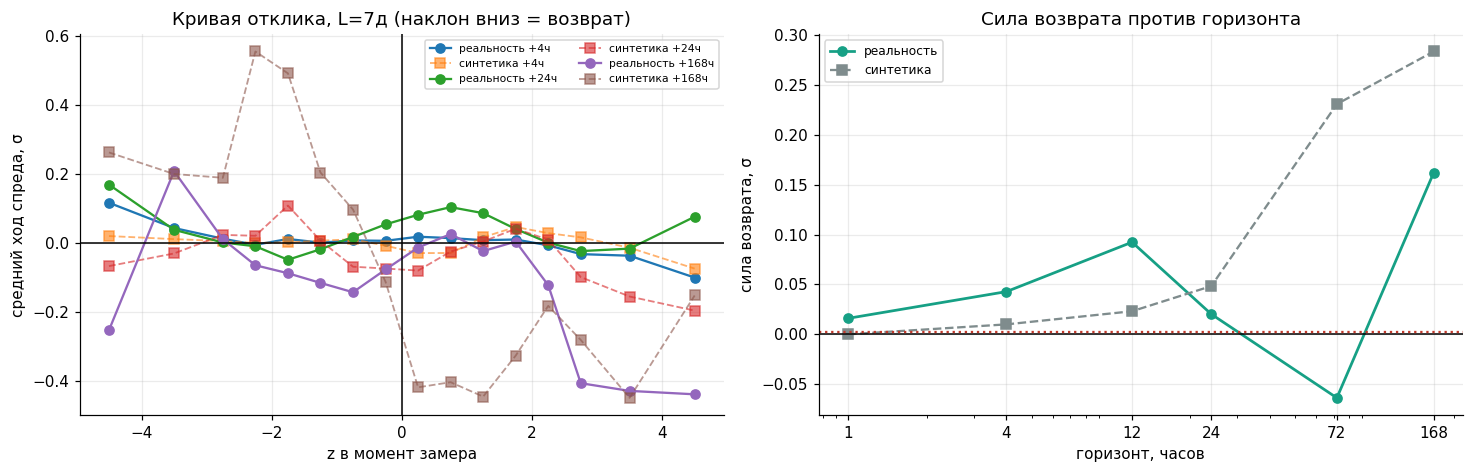

In [8]:
ZB = np.array([-np.inf, -4, -3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5, 3, 4, np.inf])
HZ = [1, 4, 12, 24, 72, 168]


def response(L, key, only_selected=True):
    """Средний форвардный ход спреда (в σ) по бакетам z. Без правил и костов."""
    T, B, MU, SD, day_ends = REFIT_FOR[key][L]
    Mx = PANELS[key]
    sel = (T < THR[L]) & (B > 0)
    n_days = len(day_ends)
    hour_day = np.full(len(HOURS), -1, dtype=int)
    for d in range(n_days):
        lo = day_ends[d] + 1
        hi = day_ends[d + 1] + 1 if d + 1 < n_days else len(HOURS)
        hour_day[lo:hi] = d
    valid = hour_day >= 0
    hd = np.clip(hour_day, 0, None)
    S = np.zeros((len(ZB) - 1, len(HZ)))
    N = np.zeros((len(ZB) - 1, len(HZ)))
    for i in range(len(PAIRS)):
        b = B[hd, i]; mu = MU[hd, i]; sd = SD[hd, i]
        okp = valid & (sel[hd, i] if only_selected else True)
        yv, xv = Mx[:, IY[i]], Mx[:, IX[i]]
        s = yv - b * xv
        z = (s - mu) / sd
        good = okp & np.isfinite(z)
        if not good.any():
            continue
        bins = np.digitize(z, ZB) - 1
        for hi_, h in enumerate(HZ):
            # ВАЖНО: forward-ход считаем при ФИКСИРОВАННОЙ на моменте t бете —
            # иначе в разность попадает скачок d_beta * log(цена) от дневного
            # рефита (та же ошибка, что была в nb05 §1).
            fwd = np.full(len(s), np.nan)
            dy = yv[h:] - yv[:-h]
            dx = xv[h:] - xv[:-h]
            fwd[:-h] = (dy - b[:-h] * dx) / sd[:-h]
            m = good & np.isfinite(fwd)
            if not m.any():
                continue
            np.add.at(S[:, hi_], bins[m], fwd[m])
            np.add.at(N[:, hi_], bins[m], 1)
    return S / np.maximum(N, 1), N


REFIT_FOR = {"real": REFIT}
M_save = M
globals()["M"] = M_null
REFIT_FOR["null"] = {L: daily_refit(L) for L in LDAYS}
globals()["M"] = M_save

LSHOW = 7
PANELS = {"real": M_real, "null": M_null}
mean_real, n_real = response(LSHOW, "real")
mean_null, n_null = response(LSHOW, "null")

labels = [f"{ZB[i]:+.1f}..{ZB[i+1]:+.1f}" for i in range(len(ZB) - 1)]
labels[0] = "< -4"; labels[-1] = "> +4"
tab = pd.DataFrame(mean_real, index=labels, columns=[f"+{h}ч" for h in HZ]).round(3)
tab["n"] = n_real[:, 0].astype(int)
print(f"ОТКЛИК СПРЕДА, L={LSHOW}д, РЕАЛЬНЫЕ данные (в σ формации)")
print("строка = где был z; столбец = средний ход спреда через N часов")
print(tab.to_string())
print()
tabn = pd.DataFrame(mean_null, index=labels, columns=[f"+{h}ч" for h in HZ]).round(3)
tabn["n"] = n_null[:, 0].astype(int)
print(f"ТО ЖЕ НА СИНТЕТИКЕ (связи нет)")
print(tabn.to_string())
print()
print("РАЗНИЦА (реальность − синтетика), только крайние бакеты:")
diff = pd.DataFrame(mean_real - mean_null, index=labels, columns=[f"+{h}ч" for h in HZ])
zc_all = np.array([(ZB[i] + ZB[i+1]) / 2 for i in range(len(ZB) - 1)])
zc_all[0], zc_all[-1] = -4.5, 4.5
extreme = np.abs(zc_all) >= 2
print(diff.loc[np.array(labels)[extreme]].round(3).to_string())
print()
print("ИНТЕРПРЕТАЦИЯ: возврат означает, что при z>0 ход ОТРИЦАТЕЛЕН, при z<0 —")
print("ПОЛОЖИТЕЛЕН (спред идёт назад к центру). Симметричную силу возврата можно")
print("свести в одно число: -sign(z) * ход, усреднённое по крайним бакетам.")
for nm, mm in [("реальность", mean_real), ("синтетика", mean_null)]:
    hi_idx = np.where((zc_all >= 2))[0]
    lo_idx = np.where((zc_all <= -2))[0]
    for hi_, h in enumerate(HZ):
        pull = (-mm[hi_idx, hi_].mean() + mm[lo_idx, hi_].mean()) / 2
        print(f"  {nm:<10} +{h:>3}ч: сила возврата {pull:+.4f}σ")
    print()

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4))
zc = [(ZB[i] + ZB[i+1]) / 2 for i in range(len(ZB) - 1)]
zc[0], zc[-1] = -4.5, 4.5
for hi_, h in enumerate(HZ):
    if h not in (4, 24, 168):
        continue
    ax[0].plot(zc, mean_real[:, hi_], "o-", lw=1.5, label=f"реальность +{h}ч")
    ax[0].plot(zc, mean_null[:, hi_], "s--", lw=1.2, alpha=0.6, label=f"синтетика +{h}ч")
ax[0].axhline(0, color="black", lw=1); ax[0].axvline(0, color="black", lw=1)
ax[0].set_xlabel("z в момент замера"); ax[0].set_ylabel("средний ход спреда, σ")
ax[0].set_title(f"Кривая отклика, L={LSHOW}д (наклон вниз = возврат)")
ax[0].legend(fontsize=7, ncol=2)

pulls_r, pulls_n = [], []
hi_idx = np.where((zc_all >= 2))[0]
lo_idx = np.where((zc_all <= -2))[0]
for hi_, h in enumerate(HZ):
    pulls_r.append((-mean_real[hi_idx, hi_].mean() + mean_real[lo_idx, hi_].mean()) / 2)
    pulls_n.append((-mean_null[hi_idx, hi_].mean() + mean_null[lo_idx, hi_].mean()) / 2)
ax[1].plot(HZ, pulls_r, "o-", lw=1.8, color="#16a085", label="реальность")
ax[1].plot(HZ, pulls_n, "s--", lw=1.5, color="#7f8c8d", label="синтетика")
ax[1].axhline(0, color="black", lw=1)
ax[1].axhline(COST / 100, color="#c0392b", ls=":", lw=1.5)
ax[1].set_xscale("log"); ax[1].set_xticks(HZ); ax[1].set_xticklabels(HZ)
ax[1].set_xlabel("горизонт, часов"); ax[1].set_ylabel("сила возврата, σ")
ax[1].set_title("Сила возврата против горизонта"); ax[1].legend(fontsize=8)
show("nb06_response")